In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
import random
from exp.exp_anomaly_detection import Exp_Anomaly_Detection
import argparse
import time
import torch.nn as nn
import math

import torch.fft as fft
from einops import rearrange, reduce, repeat

%matplotlib inline

In [70]:
class moving_avg(nn.Module):
    """
    Moving average block to highlight the trend of time series
    """

    def __init__(self, kernel_size, stride):
        super(moving_avg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # padding on the both ends of time series
        front = x[:, 0:1, :].repeat(1, self.kernel_size - 1 - math.floor((self.kernel_size - 1) // 2), 1)
        end = x[:, -1:, :].repeat(1, math.floor((self.kernel_size - 1) // 2), 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1))
        x = x.permute(0, 2, 1)
        return x

class series_decomp_multi(nn.Module):
    """
    Series decomposition block
    """

    def __init__(self, kernel_size):
        super(series_decomp_multi, self).__init__()
        self.moving_avg = [moving_avg(kernel, stride=1) for kernel in kernel_size]
        self.layer = torch.nn.Linear(1, len(kernel_size))

    def forward(self, x):
        moving_mean = []
        for func in self.moving_avg:
            moving_avg = func(x)
            moving_mean.append(moving_avg.unsqueeze(-1))
        moving_mean = torch.cat(moving_mean, dim=-1)
        moving_mean = torch.sum(moving_mean * nn.Softmax(-1)(self.layer(x.unsqueeze(-1))), dim=-1)
        res = x - moving_mean
        return res, moving_mean

In [71]:
checkpoint  = torch.load("checkpoints/dataset_re_bs128_sl96_dm16_df16_ln3_k2_embtimeF_ar20.0_lr1e-05_pt20_te50_bn1_0/checkpoint.pth")
# 如果 checkpoint 是 state_dict  
state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint 

In [72]:
# 打印所有参数名称，帮助确认命名结构  
print("All parameters in the state_dict:")  
for param_name in state_dict.keys():  
    print(param_name)
# AMS_lists.2.trend_model.layer.weight
# AMS_lists.2.trend_model.layer.bias
print("\nExtracting trend_model parameters:")  

# 提取线性层的参数（假设在模型中它被命名为 layer）
weight = state_dict["AMS_lists.2.trend_model.layer.weight"]
print("Linear Layer Weight:")  
print(weight)

bias = state_dict["AMS_lists.2.trend_model.layer.bias"]
print("Linear Layer Bias:")
print(bias)

All parameters in the state_dict:
start_fc.weight
start_fc.bias
AMS_lists.0.mean
AMS_lists.0.std
AMS_lists.0.start_linear.weight
AMS_lists.0.start_linear.bias
AMS_lists.0.trend_model.layer.weight
AMS_lists.0.trend_model.layer.bias
AMS_lists.0.experts.0.intra_embeddings
AMS_lists.0.experts.0.W_pos
AMS_lists.0.experts.0.embeddings_generator.0.0.weight
AMS_lists.0.experts.0.embeddings_generator.0.0.bias
AMS_lists.0.experts.0.embeddings_generator.1.0.weight
AMS_lists.0.experts.0.embeddings_generator.1.0.bias
AMS_lists.0.experts.0.embeddings_generator.2.0.weight
AMS_lists.0.experts.0.embeddings_generator.2.0.bias
AMS_lists.0.experts.0.embeddings_generator.3.0.weight
AMS_lists.0.experts.0.embeddings_generator.3.0.bias
AMS_lists.0.experts.0.embeddings_generator.4.0.weight
AMS_lists.0.experts.0.embeddings_generator.4.0.bias
AMS_lists.0.experts.0.embeddings_generator.5.0.weight
AMS_lists.0.experts.0.embeddings_generator.5.0.bias
AMS_lists.0.experts.0.weights_generator_distinct.memory
AMS_lists.

In [73]:
# 提取以 `trend_model` 开头的参数  
trend_model_state_dict = {k.replace("AMS_lists.2.trend_model.", ""): v for k, v in state_dict.items() if "AMS_lists.2.trend_model." in k} 
print(trend_model_state_dict) 

{'layer.weight': tensor([[ 0.2814],
        [-0.7728],
        [ 0.8108]], device='cuda:0'), 'layer.bias': tensor([0.0602, 0.9528, 0.1773], device='cuda:0')}


In [74]:
trend_model = series_decomp_multi(kernel_size=[4, 8, 12])
trend_model.load_state_dict(trend_model_state_dict)
trend_model.eval()

def seasonality_and_trend_decompose(x, trend_model=trend_model):
    from utils.Other import FourierLayer
    seasonality_model = FourierLayer(pred_len=0, k=3)
    trend_model = series_decomp_multi(kernel_size=[4, 8, 12])
    # x = x[:, :, :, 0]
    _, trend = trend_model(x)
    seasonality, _ = seasonality_model(x)
    return x + seasonality + trend

In [75]:
x = torch.randn(128,96,18)
new_x = seasonality_and_trend_decompose(x)
print("new_x shape:", new_x.shape)
x = x.numpy()
new_x = new_x.detach().cpu().numpy()

new_x shape: torch.Size([128, 96, 18])


In [76]:
print(x[0,:,0].shape)
print(new_x[0,:,0].shape)

(96,)
(96,)


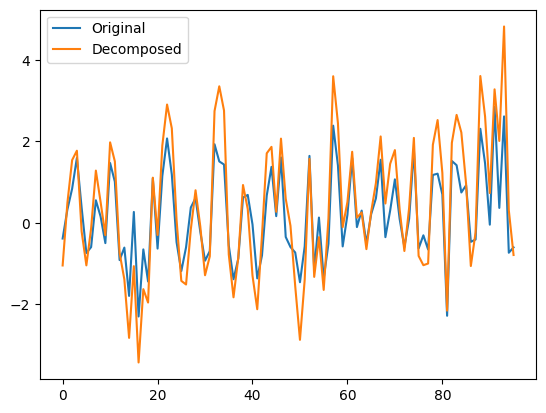

In [78]:
# 可视化x和new_x的第一个样本的第一个维度
# plt.figure(figsize=(10, 6))
plt.plot(x[1,:,1], label='Original')
plt.plot(new_x[1,:,1], label='Decomposed')
plt.legend()
plt.show()

In [79]:
test_data = np.load('label_results/dataset_re_bs128_sl96_dm16_df16_ln3_k2_embtimeF_ar20.0_lr1e-05_pt20_te50_bn1_0/test_data.npy')
print(test_data.shape)

(4480, 96, 18)


In [85]:
x = test_data[511:511+128, :, :]
x = torch.from_numpy(x).float()
new_x = seasonality_and_trend_decompose(x)
print("new_x shape:", new_x.shape)
x = x.numpy()
new_x = new_x.detach().cpu().numpy()
# print(x[0,:,0].shape)

new_x shape: torch.Size([128, 96, 18])


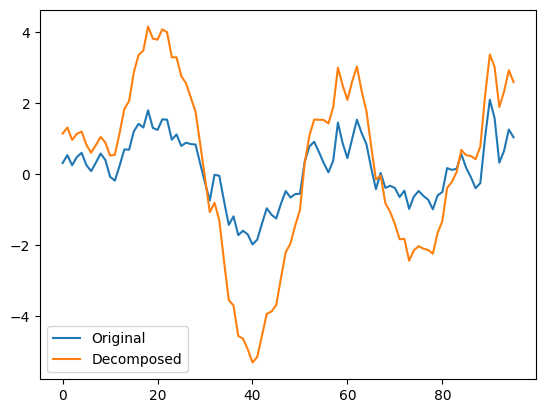

In [89]:
plt.plot(x[45,:,1], label='Original')
plt.plot(new_x[45,:,1], label='Decomposed')
plt.legend()
plt.show()

In [93]:
# 将test_data按照第0维进行划分，每128个样本一组输入到seasonality_and_trend_decompose函数中，并将结果保存到新的数组中
new_test_data = []
for i in range(0, test_data.shape[0], 128):
    x = test_data[i:i+128, :, :]
    x = torch.from_numpy(x).float()
    new_x = seasonality_and_trend_decompose(x)
    new_test_data.append(new_x.detach().cpu().numpy())
new_test_data = np.concatenate(new_test_data, axis=0)
print(new_test_data.shape)
# 保存new_test_data到文件中
np.save('label_results/dataset_re_bs128_sl96_dm16_df16_ln3_k2_embtimeF_ar20.0_lr1e-05_pt20_te50_bn1_0/test_data_decomposed.npy', new_test_data)
# 将new_test_data堆叠
new_test_data = np.concatenate(new_test_data, axis=0)
# 保存为csv文件
np.savetxt('label_results/dataset_re_bs128_sl96_dm16_df16_ln3_k2_embtimeF_ar20.0_lr1e-05_pt20_te50_bn1_0/test_data_decomposed.csv', new_test_data, delimiter=',')

(4480, 96, 18)
